# EDA – Tổng quan dữ liệu và trả lời câu hỏi

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRE_MERGED = "../data/unified/preprocessed_merged.csv"

df = pd.read_csv(PRE_MERGED, encoding="utf-8-sig", encoding_errors="ignore", on_bad_lines="skip")


## 1) Tổng quan dữ liệu

In [3]:
df.columns

Index(['tieu_de', 'gia', 'dia_chi', 'dien_tich_dat', 'phong_ngu', 'phong_tam',
       'so_tang', 'phap_ly', 'ngay_dang', 'gia_tren_m2', 'diem_sinh_loi'],
      dtype='object')

### 1.1 Ý nghĩa của từng cột dữ liệu
- tieu_de: Tiêu đề bài đăng bán nhà
- gia: Giá bán (theo tỷ đồng)
- dia_chi: Địa chỉ nhà
- dien_tich_dat: Diện tích đất (theo mét vuông)
- phong_ngu: Số phòng ngủ của nhà
- phong_tam: Số phòng tắm của nhà
- so_tang: Số tầng của nhà
- phap_ly: Tình trạng pháp lý (Sổ hồng, Số đỏ, Giấy tờ không xác định)
- ngay_dang: Ngày đăng tin bán nhà
- gia_tren_m2: Giá đất trên mét vuông 
- diem_sinh_loi: Điểm số mà dòng tiền mang lại khi cho thuê

### 1.2 Kiểu dữ liệu của từng cột hiện tại

In [4]:
df.dtypes

tieu_de           object
gia              float64
dia_chi           object
dien_tich_dat    float64
phong_ngu          int64
phong_tam          int64
so_tang            int64
phap_ly           object
ngay_dang         object
gia_tren_m2      float64
diem_sinh_loi    float64
dtype: object

### 1.3 Kiểm tra và xử lí số dòng thiếu và trùng lặp

In [5]:
print("Số dòng:", len(df))
print("Số ô missing value:", df.isna().sum().sum())
print("Số dòng bị trùng lặp (tính cả dòng giống hệt nhau):", df.duplicated().sum())



Số dòng: 6974
Số ô missing value: 0
Số dòng bị trùng lặp (tính cả dòng giống hệt nhau): 5


In [6]:
df = df.drop_duplicates(inplace=False)
print("Số dòng sau khi xoá trùng lặp:", len(df))


Số dòng sau khi xoá trùng lặp: 6969


### 1.4 Phân tích dữ liệu với các dữ liệu kiểu object

In [7]:
print("Số giá trị duy nhất của tiêu đề là: ",df['tieu_de'].nunique())
print("Số giá trị duy nhất của địa chỉ là: ", df['dia_chi'].nunique())
print("Số giá trị duy nhất của pháp lý là: ", df['phap_ly'].nunique(),df['phap_ly'].unique())
print("Số giá trị duy nhất của ngày đăng là: ", df['ngay_dang'].nunique())

df['ngay_dang'] = pd.to_datetime(df['ngay_dang'], errors='coerce')
print("Ngày đăng lớn nhất",df['ngay_dang'].min().date())
print("Ngày đăng lớn nhất:", df['ngay_dang'].max().date())

df.columns




Số giá trị duy nhất của tiêu đề là:  6431
Số giá trị duy nhất của địa chỉ là:  3433
Số giá trị duy nhất của pháp lý là:  3 ['Sổ hồng' 'Sổ đỏ' 'Giấy tờ không xác định']
Số giá trị duy nhất của ngày đăng là:  250
Ngày đăng lớn nhất 2024-10-31
Ngày đăng lớn nhất: 2025-11-28


Index(['tieu_de', 'gia', 'dia_chi', 'dien_tich_dat', 'phong_ngu', 'phong_tam',
       'so_tang', 'phap_ly', 'ngay_dang', 'gia_tren_m2', 'diem_sinh_loi'],
      dtype='object')

### 1.4 Phân tích và xử lí dữ liệu với các dữ liệu dạng numeric


In [8]:
df.describe()

,gia,dien_tich_dat,phong_ngu,phong_tam,so_tang,ngay_dang,gia_tren_m2,diem_sinh_loi
count,6969.000000,6969.000000,6969.000000,6969.000000,6969.000000,6969,6969.000000,6969.000000
mean,25.774968,75.194897,4.800402,4.736978,6.015067,2025-10-12 01:24:18.286698240,0.450439,16.743609
min,0.014000,1.500000,1.000000,1.000000,1.000000,2024-10-31 00:00:00,0.000000,3.500000
25%,6.400000,38.400000,3.000000,3.000000,3.000000,2025-10-16 00:00:00,0.130000,11.000000
50%,9.300000,54.200000,4.000000,4.000000,4.000000,2025-11-18 00:00:00,0.200000,13.000000
75%,17.600000,80.000000,5.000000,5.000000,5.000000,2025-11-25 00:00:00,0.280000,17.800000
max,9400.000000,6117.000000,100.000000,101.000000,9810.000000,2025-11-28 00:00:00,228.330000,9828.000000
std,246.665084,125.004374,4.869499,4.843872,117.520627,NaN,6.183518,117.917222


In [9]:
# Xử lí outlier dựa theo cảm quan và quan sát thủ công dữ liệu
df = df[(df['gia'] <=500) & (df['so_tang'] <= 16) & (df['phong_ngu'] <= 30) & (df['phong_tam'] <= 30) & (df['dien_tich_dat'] <= 3000)]

df.describe()

,gia,dien_tich_dat,phong_ngu,phong_tam,so_tang,ngay_dang,gia_tren_m2,diem_sinh_loi
count,6872.000000,6872.000000,6872.000000,6872.000000,6872.000000,6872,6872.000000,6872.000000
mean,16.593046,71.938161,4.510477,4.447905,4.427823,2025-10-12 02:10:45.401629696,0.224753,14.780907
min,0.014000,5.000000,1.000000,1.000000,1.000000,2024-10-31 00:00:00,0.000000,3.500000
25%,6.350000,38.000000,3.000000,3.000000,3.000000,2025-10-16 00:00:00,0.130000,11.000000
50%,9.200000,54.000000,4.000000,4.000000,4.000000,2025-11-17 00:00:00,0.200000,13.000000
75%,17.000000,80.000000,5.000000,5.000000,5.000000,2025-11-25 00:00:00,0.270000,17.000000
max,450.000000,2515.000000,30.000000,30.000000,16.000000,2025-11-28 00:00:00,9.000000,69.000000
std,25.514678,81.235701,2.978828,2.992188,2.036924,NaN,0.178864,7.008733


### 1.5 Tương quan giữa các cột numberic

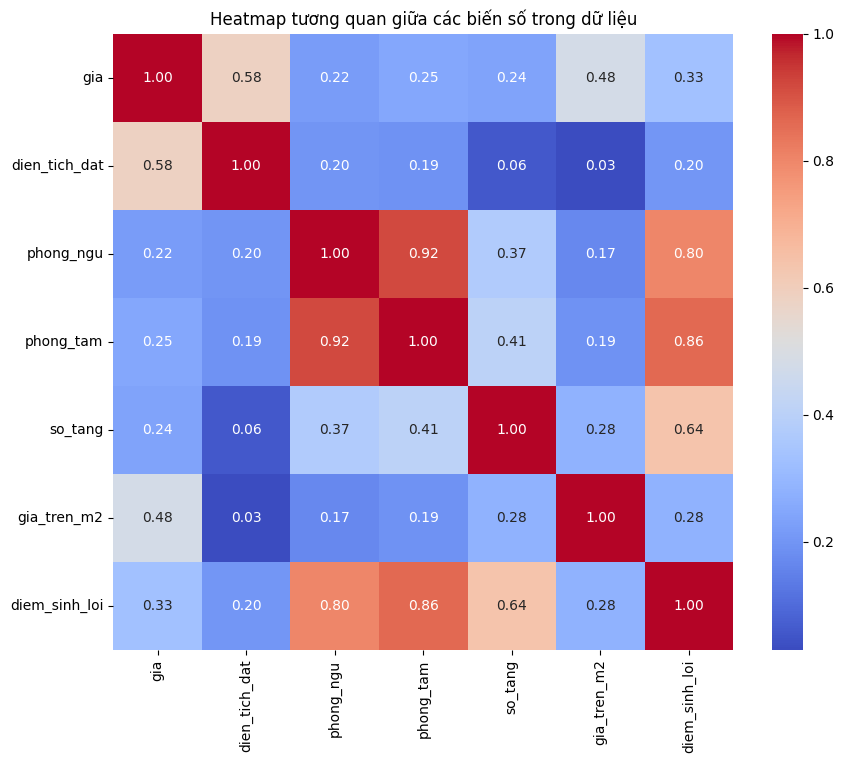

In [10]:


# Tính ma trận tương quan
corr_matrix = df.corr(numeric_only=True)

# Vẽ heatmap cho ma trận tương quan
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap tương quan giữa các biến số trong dữ liệu")
plt.show()


Nhận xét: Giá có sự tương quan mạnh nhất với diện tích đất và diem_sinh_loi có tương quan mạnh nhất với phong_ngu,phong_tam, so_tang bởi vì diem_sinh_loi chủ yếu được tính dựa trên các thuộc tính này để xem có phù hợp để cho thuê hay không

## 2) EDA để trả lời câu hỏi

### 2.1 Câu hỏi 1
-   Câu hỏi: What is the question

In [11]:
print("Code để trả lời câu hỏi ở dưới markdown này luôn")

Code để trả lời câu hỏi ở dưới markdown này luôn


Xong rồi kết luận lợi ích ở đây sau khi eda để trả lời xong

### 2.2 Câu hỏi 2
#### Câu hỏi: Ở quận nào có mức độ phân tán giá cao nhất?
    Ý nghĩa:
- Đối với nhà đầu tư cá nhân <br>
Quận có mức độ phân mảnh giá cao là nơi tồn tại đồng thời nhiều mức giá khác nhau trong cùng khu vực. Điều này tạo điều kiện cho nhà đầu tư cá nhân tìm kiếm các bất động sản được định giá thấp hơn mức trung vị của quận, từ đó tận dụng lợi thế chọn lọc vị trí thay vì phụ thuộc vào xu hướng tăng giá chung.

- Đối với nhà môi giới và công tác định giá <br>
Thị trường phân mảnh đòi hỏi phương pháp định giá dựa trên so sánh tương đồng và phân tích phân phối giá, thay vì chỉ dựa vào giá trung bình. Việc xác định các quận có phân mảnh cao giúp giảm rủi ro định giá sai do khác biệt lớn giữa các phân khúc như hẻm nhỏ và trục đường lớn.

- Đối với người mua để ở <br>
Trong các quận có phân mảnh giá cao, người mua để ở vẫn có khả năng tiếp cận các bất động sản phù hợp ngân sách, do mặt bằng giá chưa bị đẩy lên đồng loạt trên toàn quận.

- Giới hạn của phân tích <br>
Do dữ liệu chỉ được thu thập trong thời gian ngắn, kết quả phân tích chỉ phản ánh cấu trúc giá tại thời điểm hiện tại và không nhằm kết luận về xu hướng tái phát triển hay biến động giá trong dài hạn

Chuẩn bị dữ liệu

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sao chép dữ liệu
df_analysis = df.copy()

def extract_quan_huyen(address):
    if pd.isna(address):
        return np.nan
    
    # Tách các thành phần theo dấu phẩy
    parts = [p.strip() for p in address.split(',')]
    
    # Cần ít nhất 2 phần: [quận/huyện, thành phố]
    if len(parts) < 2:
        return np.nan
    
    # Lấy phần ngay trước thành phố
    quan_huyen_raw = parts[-2]
    
    return quan_huyen_raw

df_analysis['quan_huyen_raw'] = df_analysis['dia_chi'].apply(extract_quan_huyen)

df_analysis[['dia_chi', 'quan_huyen_raw']].head()

def normalize_quan_huyen(name):
    if pd.isna(name):
        return np.nan
    
    name = name.lower()
    
    # Loại bỏ các tiền tố hành chính
    prefixes = ['quận ', 'huyện ', 'thị xã ', 'tp ', 'thành phố ']
    for p in prefixes:
        if name.startswith(p):
            name = name.replace(p, '', 1)
    
    # Viết hoa chữ cái đầu mỗi từ
    name = ' '.join(word.capitalize() for word in name.split())
    
    return name

df_analysis['quan_huyen'] = df_analysis['quan_huyen_raw'].apply(normalize_quan_huyen)

df_analysis[['quan_huyen_raw', 'quan_huyen']].drop_duplicates()
# Danh sách quận/huyện duy nhất
list_quan_huyen = sorted(df_analysis['quan_huyen'].dropna().unique())

list_quan_huyen



['1',
 '10',
 '11',
 '12',
 '2 (tp. Thủ Đức)',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9 (tp. Thủ Đức)',
 'Ba Đình',
 'Biên Giang',
 'Bình Thạnh',
 'Bình Tân',
 'Bưởi',
 'Bắc Từ Liêm',
 'Bắc Từ Liêm Hà Nội Đường Cổ Nhuế',
 'Bắc Từ Liêm Hà Nội Đường Trung Tựu',
 'Bồ Đề',
 'Cầu Diễn',
 'Cầu Giấy',
 'Cổ Nhuế 2',
 'Cự Khối',
 'Gò Vấp',
 'Hai Bà Trưng',
 'Hoàn Kiếm',
 'Hoàng Liệt',
 'Hoàng Mai',
 'Hoàng Mai Hà Nội Đường Nguyễn Chính',
 'Hà Nội Hoàng Mai Đường Bằng Liệt',
 'Hà Nội Hà Đông Đường Hòa Bình',
 'Hà Nội Hà Đông Đường Quang Trung',
 'Hà Nội Long Biên Đường Ngọc Trì',
 'Hà Nội Tây Hồ Đường Tứ Liên',
 'Hà Đông',
 'Hà Đông Hà Nội Đường 1',
 'Hồ Chí Minh',
 'Long Biên',
 'Long Biên Hà Nội Đường Gia Quất',
 'Long Biên Hà Nội Đường Ngô Gia Tự',
 'Long Biên Hà Nội Đường Ngọc Thụy',
 'Long Biên Hà Nội Đường Đàm Quang Trung',
 'Lĩnh Nam',
 'Minh Khai',
 'Mễ Trì',
 'Mộ Lao',
 'Mỹ Đình 1',
 'Nam Từ Liêm',
 'Nam Từ Liêm Hà Nội Đường Lê Quang Đạo',
 'Nam Từ Liêm Hà Nội Đường Miêu Nha',
 'Nam Từ L

## Biến và thước đo sử dụng

Phân tích tập trung vào biến `gia_tren_m2` nhằm loại bỏ ảnh hưởng của diện tích bất động sản.

Mức độ phân mảnh giá trong mỗi quận được đo bằng các chỉ số:
- Giá trung bình (mean)
- Giá trung vị (median)
- Độ lệch chuẩn (standard deviation)
- Hệ số biến thiên (Coefficient of Variation – CV)
- Khoảng tứ phân vị (IQR)

Trong đó, hệ số biến thiên (CV) được sử dụng làm chỉ số chính để so sánh mức độ phân mảnh giữa các quận do đã chuẩn hóa theo mặt bằng giá.


In [13]:
def calc_iqr(x):
    return np.percentile(x, 75) - np.percentile(x, 25)

summary_by_quan = (
    df_analysis
    .groupby('quan')['gia_tren_m2']
    .agg(
        so_luong='count',
        mean='mean',
        median='median',
        std='std',
        iqr=calc_iqr
    )
    .reset_index()
)

summary_by_quan['cv'] = summary_by_quan['std'] / summary_by_quan['mean']
summary_by_quan = summary_by_quan.sort_values(by='cv', ascending=False)

summary_by_quan


KeyError: 'quan'

## Trực quan hóa phân phối giá trên mỗi mét vuông

Biểu đồ boxplot được sử dụng để quan sát trực quan mức độ phân tán và hình dạng phân phối giá bất động sản trong từng quận.


In [ ]:
plt.figure(figsize=(10, 6))

df_analysis.boxplot(
    column='gia_tren_m2',
    by='quan',
    grid=False
)

plt.title('Phân phối giá trên mỗi m² theo quận')
plt.suptitle('')
plt.xlabel('Quận')
plt.ylabel('Giá trên mỗi m²')
plt.show()


## So sánh giá trung bình và giá trung vị

Sự chênh lệch giữa giá trung bình và giá trung vị phản ánh mức độ lệch của phân phối giá. Khi giá trung bình cao hơn đáng kể so với giá trung vị, điều này cho thấy phân phối bị kéo bởi một nhóm bất động sản có giá cao.


In [ ]:
plt.figure(figsize=(10, 6))

x = np.arange(len(summary_by_quan))
width = 0.35

plt.bar(x - width/2, summary_by_quan['mean'], width, label='Mean')
plt.bar(x + width/2, summary_by_quan['median'], width, label='Median')

plt.xticks(x, summary_by_quan['quan'])
plt.ylabel('Giá trên mỗi m²')
plt.title('So sánh giá trung bình và trung vị theo quận')
plt.legend()
plt.show()


## Phân tích khả năng tiếp cận bất động sản giá thấp

Ngoài mức độ phân tán, phân tích tỷ lệ bất động sản có giá trên mỗi mét vuông thấp hơn giá trung vị của quận giúp đánh giá khả năng tìm kiếm các bất động sản có mức giá hợp lý trong từng khu vực.


In [ ]:
df_analysis = df_analysis.merge(
    summary_by_quan[['quan', 'median']],
    on='quan',
    how='left'
)

df_analysis['duoi_median'] = df_analysis['gia_tren_m2'] < df_analysis['median']

ratio_below_median = (
    df_analysis
    .groupby('quan')['duoi_median']
    .mean()
    .reset_index(name='ty_le_duoi_median')
)

plt.figure(figsize=(8, 5))
plt.bar(ratio_below_median['quan'], ratio_below_median['ty_le_duoi_median'])
plt.ylabel('Tỷ lệ BĐS có giá dưới median')
plt.title('Khả năng tiếp cận BĐS giá thấp theo quận')
plt.show()


#### Trả lời câu hỏi 2


### 2.3 Câu hỏi 3

### 2.4 Câu hỏi 4

### 2.5 Câu hỏi 5